<a href="https://colab.research.google.com/github/shreyashahi30/Tredence_Case_Study/blob/main/Self_Pruning_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

BATCH_SIZE = 128
EPOCHS = 15
LR = 0.001
LAMBDA_VALUES = [1e-5, 1e-4, 1e-3]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
torch.manual_seed(42)

print("Starting script...")
print("Using device:", DEVICE)

print("Loading CIFAR-10 dataset...")

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.ToTensor()
])

train_ds = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_ds = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Dataset loaded successfully.")


class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.02
        )
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features)
        )

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

class SelfPruningCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc1 = PrunableLinear(64 * 8 * 8, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

def compute_sparsity_loss(model):
    loss = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            loss += module.get_gates().sum()

    return loss


def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = module.get_gates()

            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total


def collect_all_gates(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = module.get_gates().detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    return np.array(all_gates)

def train_model(lambda_value):
    print(f"\nTraining model with lambda = {lambda_value}")

    model = SelfPruningCNN().to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    best_state = None
    history = []

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0

        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for images, labels in progress:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            ce_loss = criterion(outputs, labels)
            sparsity_loss = compute_sparsity_loss(model)

            loss = ce_loss + lambda_value * sparsity_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        acc = evaluate(model)
        history.append(acc)

        print(
            f"Epoch {epoch+1}: "
            f"Loss={running_loss:.2f}, "
            f"Accuracy={acc:.2f}%"
        )

        if acc > best_acc:
            best_acc = acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    final_acc = evaluate(model)
    sparsity = calculate_sparsity(model)
    gates = collect_all_gates(model)

    return model, final_acc, sparsity, history, gates

def main():
    print("Starting training process...")

    results = []

    best_model = None
    best_acc = 0
    best_history = None
    best_gates = None

    for lam in LAMBDA_VALUES:
        model, acc, sparsity, history, gates = train_model(lam)

        results.append({
            "Lambda": lam,
            "Accuracy": round(acc, 2),
            "Sparsity %": round(sparsity, 2)
        })

        if acc > best_acc:
            best_acc = acc
            best_model = model
            best_history = history
            best_gates = gates

    torch.save(
        best_model.state_dict(),
        os.path.join(OUTPUT_DIR, "best_model.pth")
    )

    df = pd.DataFrame(results)
    csv_path = os.path.join(OUTPUT_DIR, "results.csv")
    df.to_csv(csv_path, index=False)

    print("\nFinal Results:")
    print(df)

    plt.figure(figsize=(8, 5))
    plt.plot(best_history, marker="o")
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy %")
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, "training_curve.png"))
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.hist(best_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Count")
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, "gate_histogram.png"))
    plt.close()

    print("\nSaved files inside outputs folder:")
    print("best_model.pth")
    print("results.csv")
    print("training_curve.png")
    print("gate_histogram.png")


if __name__ == "__main__":
    main()

Starting script...
Using device: cpu
Loading CIFAR-10 dataset...
Dataset loaded successfully.
Starting training process...

Training model with lambda = 1e-05


Epoch 1/15: 100%|██████████| 391/391 [00:59<00:00,  6.62it/s]


Epoch 1: Loss=2657.50, Accuracy=42.96%


Epoch 2/15: 100%|██████████| 391/391 [00:59<00:00,  6.60it/s]


Epoch 2: Loss=2230.01, Accuracy=51.77%


...

Epoch 13: Loss=15299.36, Accuracy=65.79%


Epoch 14/15: 100%|██████████| 391/391 [01:01<00:00,  6.33it/s]


Epoch 14: Loss=12818.69, Accuracy=67.41%


Epoch 15/15: 100%|██████████| 391/391 [01:03<00:00,  6.18it/s]


Epoch 15: Loss=10803.84, Accuracy=67.38%

Final Results:
    Lambda  Accuracy  Sparsity %
0  0.00001     72.44        8.42
1  0.00010     70.14       11.21
2  0.00100     67.41        9.47

Saved files inside outputs folder:
best_model.pth
results.csv
training_curve.png
gate_histogram.png


In [ ]:
!ls /content/outputs

best_model.pth	gate_histogram.png  results.csv  training_curve.png


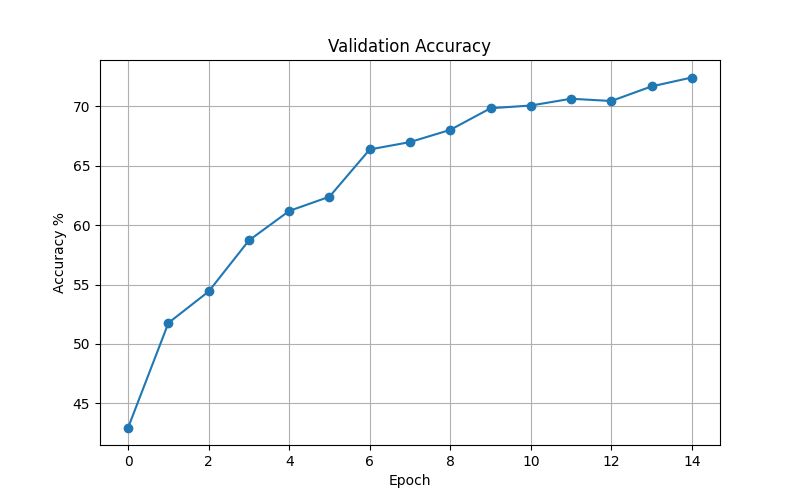

In [ ]:
from IPython.display import Image
Image('/content/outputs/training_curve.png')

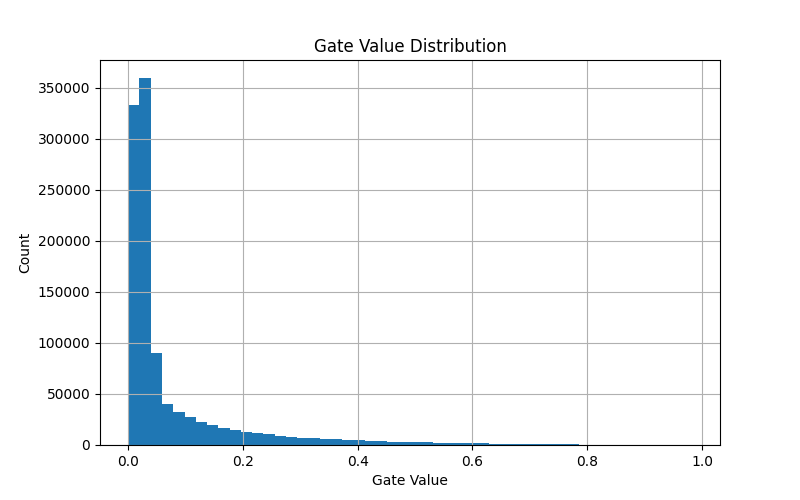

In [ ]:
from IPython.display import Image
Image('/content/outputs/gate_histogram.png')

In [ ]:
import pandas as pd
df = pd.read_csv('/content/outputs/results.csv')
print(df)

    Lambda  Accuracy  Sparsity %
0  0.00001     72.44        8.42
1  0.00010     70.14       11.21
2  0.00100     67.41        9.47
